In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path=r"M:\NYC\train.csv"

In [4]:
def load_and_prepare_data(filepath):
    print("📊 Loading data...")
    df = pd.read_csv(filepath)
    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
    df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"])
    print(f"✅ Data loaded: {df.shape}")
    return df

In [5]:
df=load_and_prepare_data(file_path)
df.head()

📊 Loading data...
✅ Data loaded: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [6]:
def basic_eda(df):
    print("\n" + "="*50)
    print("📈 BASIC EDA")
    print("="*50)
    print(f"Dataset shape: {df.shape}")
    print(f"\nDataset info:")
    print(df.info())
    print(f"\nBasic statistics:")
    print(df.describe())
    print(f"\nMissing values:")
    print(df.isna().sum())
    print(f"\nUnique values:")
    print(df.nunique())

In [7]:
basic_eda(df)


📈 BASIC EDA
Dataset shape: (1458644, 11)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   dropoff_datetime    1458644 non-null  datetime64[ns]
 4   passenger_count     1458644 non-null  int64         
 5   pickup_longitude    1458644 non-null  float64       
 6   pickup_latitude     1458644 non-null  float64       
 7   dropoff_longitude   1458644 non-null  float64       
 8   dropoff_latitude    1458644 non-null  float64       
 9   store_and_fwd_flag  1458644 non-null  object        
 10  trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](2), float64(4), int64(3), object(2)
memory usage: 122

In [8]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

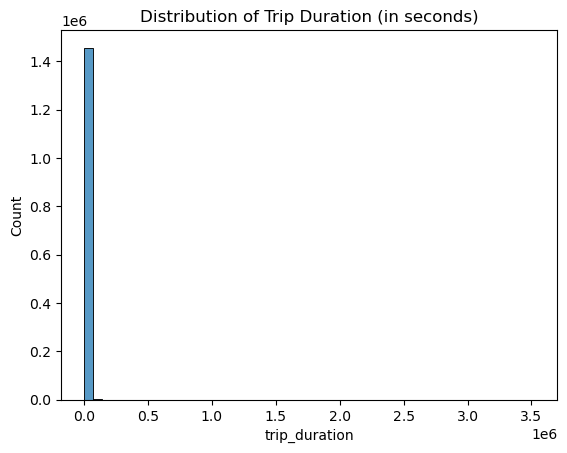

In [9]:
sns.histplot(df['trip_duration'], bins=50, kde=False)
plt.title('Distribution of Trip Duration (in seconds)')
plt.show()

In [10]:
def process_trip_duration(df):
    df = df[df["trip_duration"] > 0]
    df["log_trip_duration"] = np.log1p(df["trip_duration"])
    return df

In [11]:
df = process_trip_duration(df)

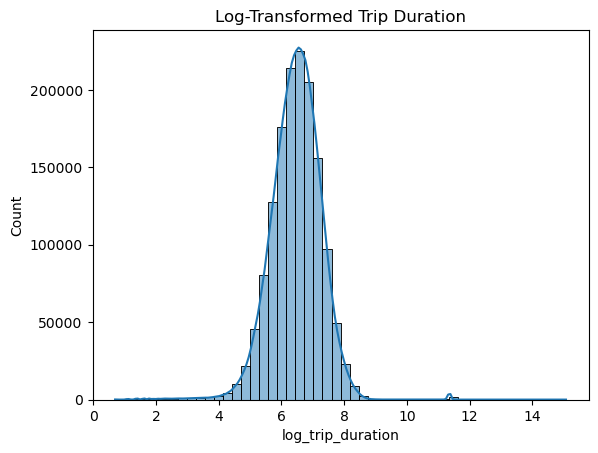

In [12]:
sns.histplot(df['log_trip_duration'],bins=50,kde=True)
plt.title('Log-Transformed Trip Duration')
plt.show()

In [13]:
def extract_time_features(df):
    print("\n🕐 Extracting time features...")
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["pickup_month"] = df["pickup_datetime"].dt.month
    df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
    df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)
    
    print("✅ Time features extracted:")
    print(f"   - pickup_hour: {df['pickup_hour'].nunique()} unique values")
    print(f"   - pickup_month: {df['pickup_month'].nunique()} unique values") 
    print(f"   - pickup_dayofweek: {df['pickup_dayofweek'].nunique()} unique values")
    print(f"   - is_weekend: {df['is_weekend'].nunique()} unique values")
    
    return df

In [14]:
df=extract_time_features(df)
df.head()


🕐 Extracting time features...
✅ Time features extracted:
   - pickup_hour: 24 unique values
   - pickup_month: 6 unique values
   - pickup_dayofweek: 7 unique values
   - is_weekend: 2 unique values


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,pickup_hour,pickup_month,pickup_dayofweek,is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,6.122493,17,3,0,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,6.498282,0,6,6,1
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,7.661527,11,1,1,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,6.063785,19,4,2,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,6.077642,13,3,5,1


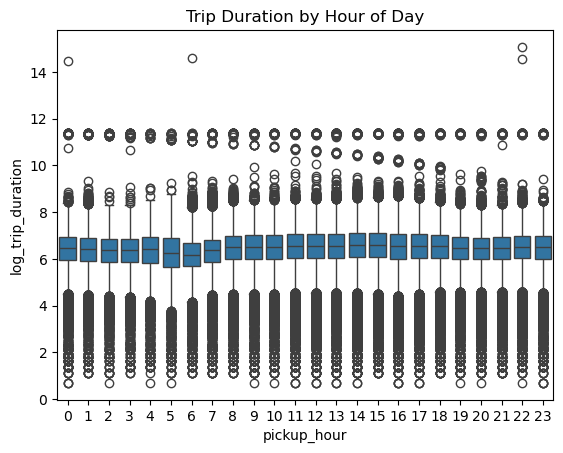

In [15]:
sns.boxplot(x=df["pickup_hour"],y=df["log_trip_duration"])
plt.title("Trip Duration by Hour of Day")
plt.show()

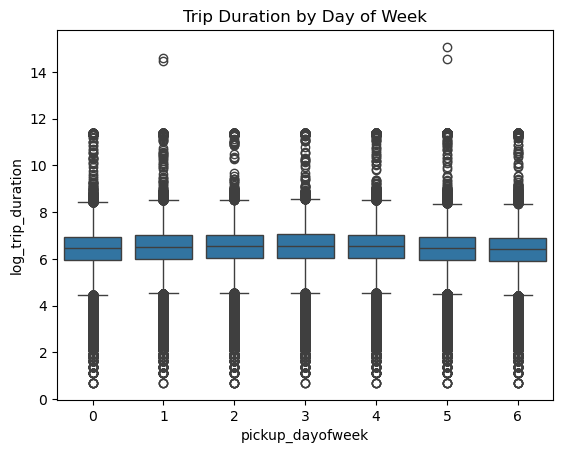

In [16]:
sns.boxplot(x=df["pickup_dayofweek"],y=df["log_trip_duration"])
plt.title('Trip Duration by Day of Week')
plt.show()

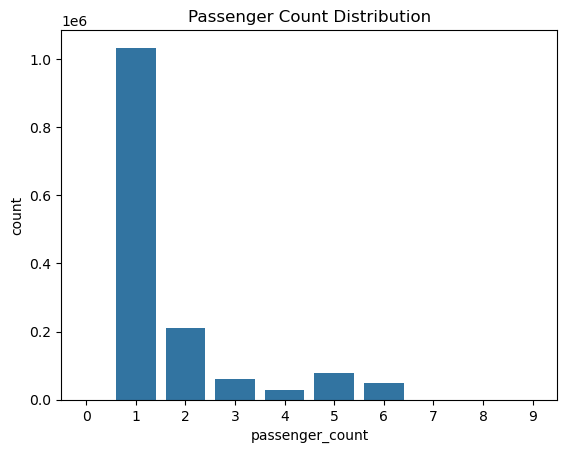

In [17]:
sns.countplot(x='passenger_count', data=df)
plt.title('Passenger Count Distribution')
plt.show()

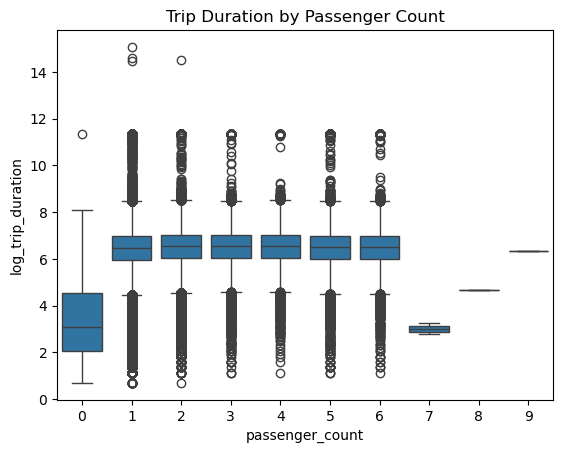

In [18]:
sns.boxplot(x='passenger_count', y='log_trip_duration', data=df)
plt.title('Trip Duration by Passenger Count')
plt.show()

In [19]:
from math import radians, sin, cos, sqrt, atan2

In [20]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [21]:
def calculate_bearing(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = sin(dlon) * cos(lat2)
    y = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dlon)
    bearing = atan2(x, y)
    bearing = np.degrees(bearing)
    return (bearing + 360) % 360

In [22]:
def add_geo_features(df):
    print("\n📍 Adding geographical features...")
    df['distance_km'] = df.apply(lambda row: haversine(
        row['pickup_longitude'], row['pickup_latitude'],
        row['dropoff_longitude'], row['dropoff_latitude']
    ), axis=1)
    
    df['speed_kph'] = df['distance_km'] / (df['trip_duration'] / 3600)
    
    df['bearing'] = df.apply(lambda row: calculate_bearing(
        row['pickup_longitude'], row['pickup_latitude'],
        row['dropoff_longitude'], row['dropoff_latitude']
    ), axis=1)
    
    df['manhattan_distance'] = (
        abs(df['pickup_latitude'] - df['dropoff_latitude']) + 
        abs(df['pickup_longitude'] - df['dropoff_longitude'])
    ) * 111  # Approximate km per degree

    print("✅ Geographical features added:")
    print(f"   - distance_km: mean={df['distance_km'].mean():.2f} km")
    print(f"   - speed_kph: mean={df['speed_kph'].mean():.2f} kph")
    print(f"   - bearing: range=[0, 360] degrees")
    print(f"   - manhattan_distance: mean={df['manhattan_distance'].mean():.2f} km")
    return df

In [23]:
df = add_geo_features(df)


📍 Adding geographical features...
✅ Geographical features added:
   - distance_km: mean=3.44 km
   - speed_kph: mean=14.42 kph
   - bearing: range=[0, 360] degrees
   - manhattan_distance: mean=5.10 km


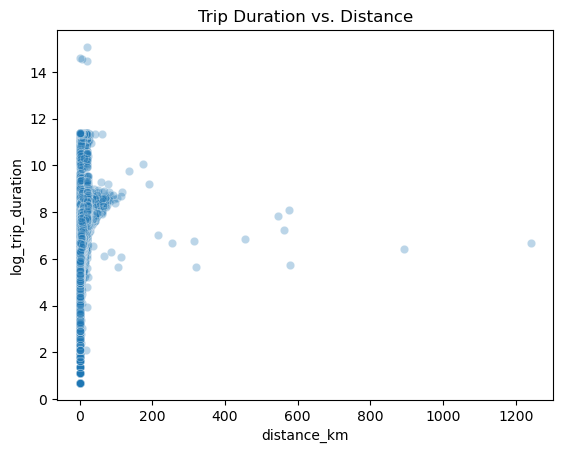

In [24]:
sns.scatterplot(x='distance_km', y='log_trip_duration', data=df, alpha=0.3)
plt.title('Trip Duration vs. Distance')
plt.show()

In [25]:
def clean_data(df):
    print("\n🧹 Cleaning data...")
    initial_count = len(df)
    
    # Remove outliers
    df = df[
        (df['distance_km'] > 0.1) & 
        (df['distance_km'] < 100) &
        (df['speed_kph'] < 200) &
        (df["trip_duration"] > 10) & 
        (df["trip_duration"] < 10800)  # 3 hours max
    ]
    
    final_count = len(df)
    removed_count = initial_count - final_count
    print(f"✅ Removed {removed_count} outliers ({removed_count/initial_count*100:.1f}%)")
    print(f"   Final shape: {df.shape}")
    
    return df

In [26]:
df=clean_data(df)


🧹 Cleaning data...
✅ Removed 15590 outliers (1.1%)
   Final shape: (1443054, 20)


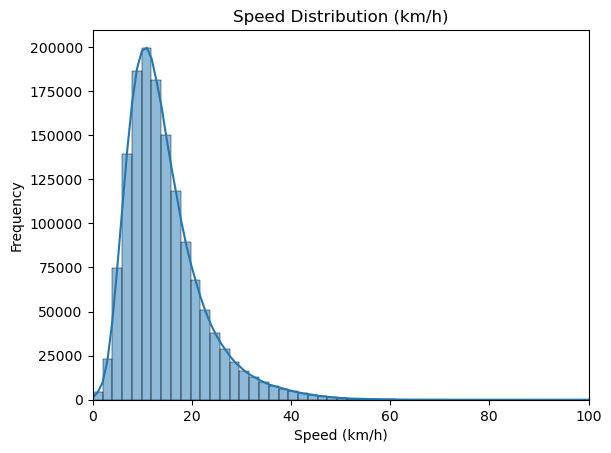

In [27]:
sns.histplot(x='speed_kph', bins=100, kde=True,data=df)
plt.title('Speed Distribution (km/h)')
plt.xlim(0, 100)
plt.xlabel('Speed (km/h)')
plt.ylabel('Frequency')
plt.show()

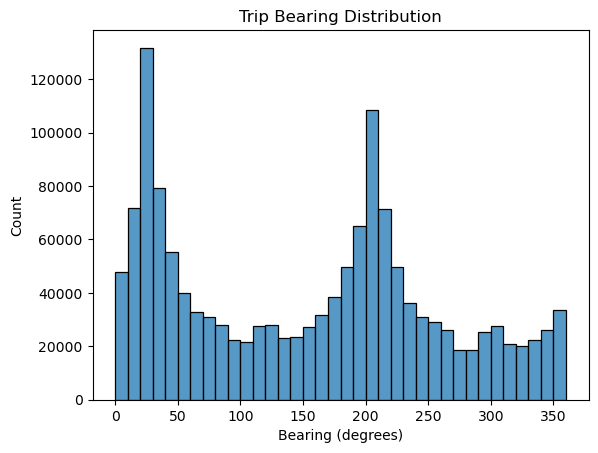

In [28]:
sns.histplot(df['bearing'], bins=36, kde=False)  # تقسيم الدرجات إلى 10° لكل خانة
plt.title('Trip Bearing Distribution')
plt.xlabel('Bearing (degrees)')
plt.show()

In [29]:
import folium
from folium.plugins import MarkerCluster

sample_df = df.sample(500, random_state=42)

map_center = [40.75, -73.98]
m = folium.Map(location=map_center, zoom_start=12)

marker_cluster = MarkerCluster().add_to(m)

for idx, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['pickup_latitude'], row['pickup_longitude']],
        radius=3,
        color='green',
        fill=True,
        fill_opacity=0.7,
        popup=f"Vendor: {row['vendor_id']}<br>Duration: {row['trip_duration']}s"
    ).add_to(marker_cluster)
    
    folium.CircleMarker(
        location=[row['dropoff_latitude'], row['dropoff_longitude']],
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)

m


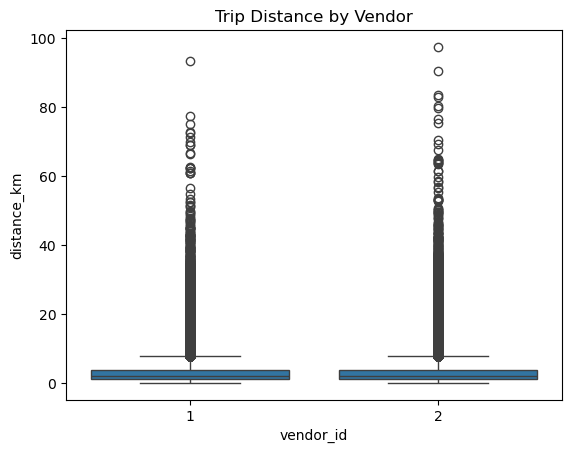

In [30]:
sns.boxplot(x='vendor_id', y='distance_km', data=df)
plt.title('Trip Distance by Vendor')
plt.show()

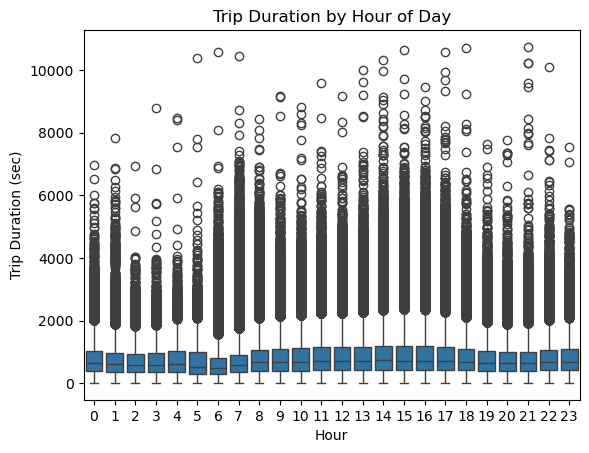

In [31]:
sns.boxplot(x='pickup_hour', y='trip_duration', data=df)
plt.title('Trip Duration by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Trip Duration (sec)')
plt.show()

In [32]:
df['pickup_lat_rounded'] = df['pickup_latitude'].round(2)
df['pickup_lon_rounded'] = df['pickup_longitude'].round(2)

heatmap_hour = df.groupby(['pickup_lat_rounded', 'pickup_lon_rounded', 'pickup_hour']).size().reset_index(name='num_trips')

heatmap_day = df.groupby(['pickup_lat_rounded', 'pickup_lon_rounded', 'pickup_dayofweek']).size().reset_index(name='num_trips')


In [33]:
from folium.plugins import HeatMap

selected_hour = 8
df_hour = heatmap_hour[heatmap_hour['pickup_hour'] == selected_hour]

m = folium.Map(location=[40.75, -73.98], zoom_start=12)
heat_data = list(zip(df_hour['pickup_lat_rounded'], df_hour['pickup_lon_rounded'], df_hour['num_trips']))
HeatMap(heat_data, radius=10, blur=15).add_to(m)
m

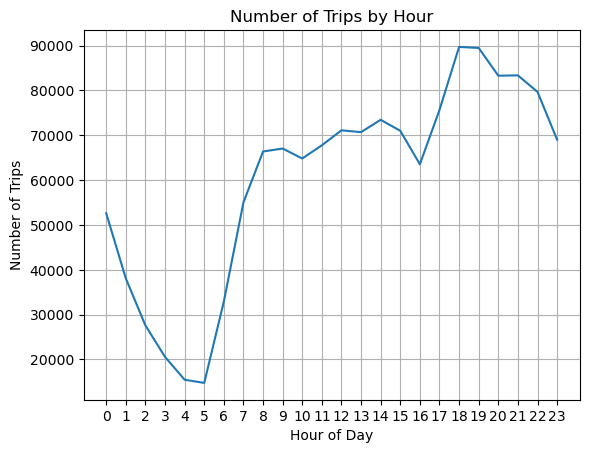

In [34]:
hourly_counts = df['pickup_hour'].value_counts().sort_index()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title("Number of Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24)) 
plt.grid(True)
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

def encode_categoricals(df):
    encoded_cols=[]
    print("\n🔤 Encoding categorical variables...")
    for col in ['vendor_id', 'store_and_fwd_flag']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoded_cols.append(col)
    print(f"✅ Encoded columns: {encoded_cols}")
    return df

In [36]:
df = encode_categoricals(df)


🔤 Encoding categorical variables...
✅ Encoded columns: ['vendor_id', 'store_and_fwd_flag']


In [37]:
def prepare_features(df):
    print("\n🎯 Preparing features...")
    categorical_features = ['vendor_id', 'passenger_count', 'pickup_dayofweek', 'is_weekend']
    numerical_features = [
        'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
        'distance_km', 'bearing', 'pickup_hour', 'manhattan_distance', 'pickup_month'
    ]
    
    categorical_features = [col for col in categorical_features if col in df.columns]
    numerical_features = [col for col in numerical_features if col in df.columns]
    all_features = categorical_features + numerical_features
    
    X = df[all_features]
    y = df['log_trip_duration']
    print(f"✅Features prepared:")
    print(f"  Categorical: {len(categorical_features)} features: {categorical_features}")
    print(f"  Numerical: {len(numerical_features)} features: {numerical_features}")
    print(f"  Total: {len(all_features)} features")
    print(f"🎯Target: log_trip_duration")

    return X, y

In [38]:
X,y=prepare_features(df)
X.head()


🎯 Preparing features...
✅Features prepared:
  Categorical: 4 features: ['vendor_id', 'passenger_count', 'pickup_dayofweek', 'is_weekend']
  Numerical: 9 features: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'distance_km', 'bearing', 'pickup_hour', 'manhattan_distance', 'pickup_month']
  Total: 13 features
🎯Target: log_trip_duration


,vendor_id,passenger_count,pickup_dayofweek,is_weekend,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,bearing,pickup_hour,manhattan_distance,pickup_month
0,1,1,0,0,-73.982155,40.767937,-73.964630,40.765602,1.498521,99.970196,17,2.204384,3
1,0,1,6,1,-73.980415,40.738564,-73.999481,40.731152,1.805507,242.846232,0,2.939037,6
2,1,1,1,0,-73.979027,40.763939,-74.005333,40.710087,6.385098,200.319835,11,8.897564,1
3,1,1,2,0,-74.010040,40.719971,-74.012268,40.706718,1.485498,187.262300,19,1.718285,4
4,1,1,5,1,-73.973053,40.793209,-73.972923,40.782520,1.188588,179.473585,13,1.200851,3


C:\Users\mahmo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


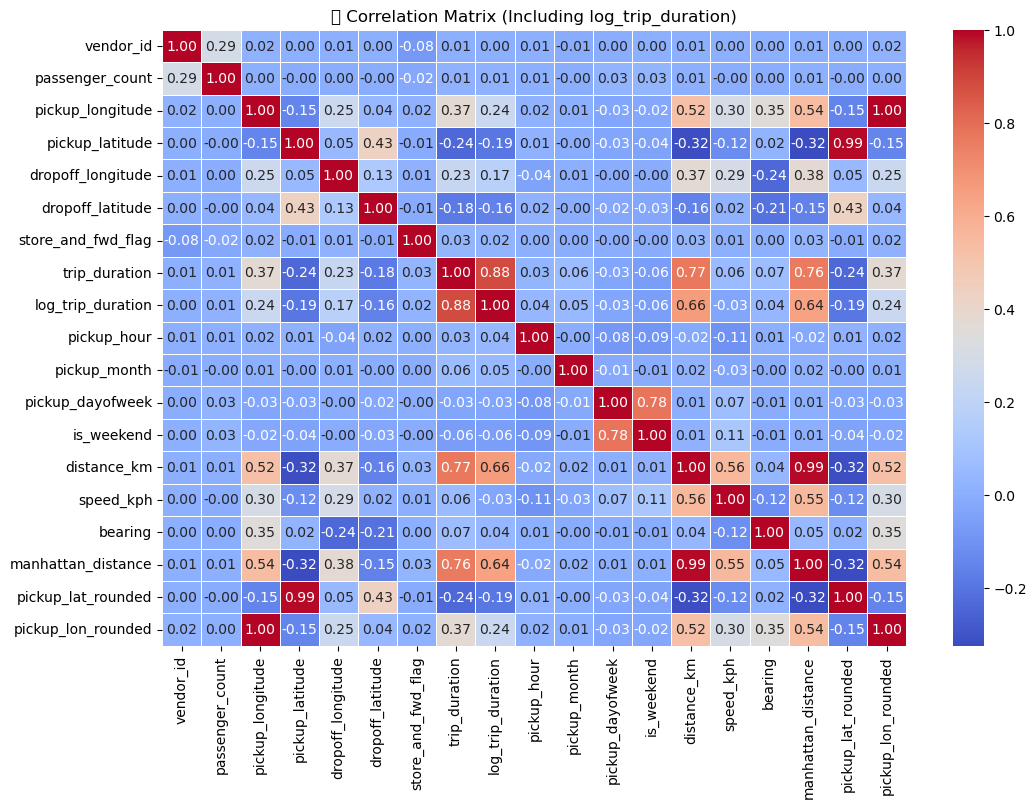

In [39]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_data = df[numerical_cols]
corr_matrix = correlation_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("📈 Correlation Matrix (Including log_trip_duration)")
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
def train_and_evaluate_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"📊 Linear Regression:\nRMSE = {rmse:.3f}, R² = {r2:.3f}")
    return model

In [41]:
model = train_and_evaluate_model(X, y)

📊 Linear Regression:
RMSE = 0.532, R² = 0.479
